**IMPUTATION**


•	Imputation is the process of replacing missing values in a dataset using statistical or model-based techniques to preserve data integrity and avoid information loss.

In [ ]:
import pandas as pd
import numpy as np
from sklearn.impute import SimpleImputer

# Load the full Titanic CSV

df = pd.read_csv("Titanic-Dataset.csv")

# Show basic info
print("Original Data Info:")
print(df.info())

# Show missing values count
print("\nMissing values per column:")
print(df.isnull().sum())


Original Data Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB
None

Missing values per column:
PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
C

1️⃣ Mean Imputation

For a numeric column like age:

In [ ]:
mean_imp = SimpleImputer(strategy="mean")
df["Age"] = mean_imp.fit_transform(df[["Age"]])
print("the mean age is", df["Age"].mean())
print("\nAfter mean imputation (age):")
print(df["Age"].isnull().sum())
print(df["Age"].head(50))


the mean age is 29.69911764705882

After mean imputation (age):
0
0     22.000000
1     38.000000
2     26.000000
3     35.000000
4     35.000000
5     29.699118
6     54.000000
7      2.000000
8     27.000000
9     14.000000
10     4.000000
11    58.000000
12    20.000000
13    39.000000
14    14.000000
15    55.000000
16     2.000000
17    29.699118
18    31.000000
19    29.699118
20    35.000000
21    34.000000
22    15.000000
23    28.000000
24     8.000000
25    38.000000
26    29.699118
27    19.000000
28    29.699118
29    29.699118
30    40.000000
31    29.699118
32    29.699118
33    66.000000
34    28.000000
35    42.000000
36    29.699118
37    21.000000
38    18.000000
39    14.000000
40    40.000000
41    27.000000
42    29.699118
43     3.000000
44    19.000000
45    29.699118
46    29.699118
47    29.699118
48    29.699118
49    18.000000
Name: Age, dtype: float64


2️⃣ Median Imputation

For numeric columns with outliers like fare:

In [ ]:
median_imp = SimpleImputer(strategy="median")
df["Fare"] = median_imp.fit_transform(df[["Fare"]])

print("\nAfter median imputation (Fare):")
print(df["Fare"].isnull().sum())



After median imputation (Fare):
0


3️⃣ Mode (Most Frequent)

For a categorical feature like embarked:

In [ ]:
mode_imp = SimpleImputer(strategy="most_frequent")

df["Embarked"] = mode_imp.fit_transform(df[["Embarked"]]).ravel()

print("After mode imputation (Embarked):")
print(df["Embarked"].isnull().sum())


After mode imputation (Embarked):
0


You can also impute multiple columns at once:

In [ ]:
imputer = SimpleImputer(strategy="median")
df_num = df.select_dtypes(include=["float64", "int64"])
df[df_num.columns] = imputer.fit_transform(df_num)

print("\nAfter median imputation for numeric columns:")
print(df_num.isnull().sum())



After median imputation for numeric columns:
PassengerId    0
Survived       0
Pclass         0
Age            0
SibSp          0
Parch          0
Fare           0
dtype: int64


In [ ]:
print(df["Age"].head(50))

0     22.000000
1     38.000000
2     26.000000
3     35.000000
4     35.000000
5     29.699118
6     54.000000
7      2.000000
8     27.000000
9     14.000000
10     4.000000
11    58.000000
12    20.000000
13    39.000000
14    14.000000
15    55.000000
16     2.000000
17    29.699118
18    31.000000
19    29.699118
20    35.000000
21    34.000000
22    15.000000
23    28.000000
24     8.000000
25    38.000000
26    29.699118
27    19.000000
28    29.699118
29    29.699118
30    40.000000
31    29.699118
32    29.699118
33    66.000000
34    28.000000
35    42.000000
36    29.699118
37    21.000000
38    18.000000
39    14.000000
40    40.000000
41    27.000000
42    29.699118
43     3.000000
44    19.000000
45    29.699118
46    29.699118
47    29.699118
48    29.699118
49    18.000000
Name: Age, dtype: float64


Quick Summary


Use SimpleImputer with strategies like:

"mean" → numeric averages

"median" → robust to outliers

"most_frequent" → for categorical data

Always inspect missing counts with df.isnull().sum() before and after imputation.

Load the CSV Dataset

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("Book2.csv")
df.head(50)


,ID,Employee_Name,Experience_Years,Age,Gender,Salary
0,1,Anu,5,28,Female,250000
1,2,Rahul,1,21,Male,50000
2,3,Meena,3,23,Female,170000
3,4,Arun,2,22,Male,25000
4,5,Kiran,1,17,Male,10000
5,6,Suresh,25,62,Male,5001000
6,7,Divya,19,54,Female,800000
7,8,Neha,2,21,Female,9000
8,9,Priya,10,36,Female,61500
9,10,Kavya,15,54,Female,650000


2️⃣ Handling Duplicates
🔍 Check duplicate rows

In [ ]:
print(df.duplicated(subset=["Employee_Name", "Age", "Salary"], keep=False).sum())

4


View duplicate records

In [ ]:
df[df.duplicated(subset=["Employee_Name", "Age", "Salary"], keep=False)]


,ID,Employee_Name,Experience_Years,Age,Gender,Salary
2,3,Meena,3,23,Female,170000
10,11,Anjali,4,26,Female,250000
35,36,Meena,3,23,Female,170000
36,37,Anjali,4,26,Female,250000


Add duplicate flag

In [ ]:
df["Is_Duplicate"] = df.duplicated(subset=["Employee_Name", "Age", "Salary"])
df.head(150)


,ID,Employee_Name,Experience_Years,Age,Gender,Salary,Is_Duplicate
0,1,Anu,5,28,Female,250000,False
1,2,Rahul,1,21,Male,50000,False
2,3,Meena,3,23,Female,170000,False
3,4,Arun,2,22,Male,25000,False
4,5,Kiran,1,17,Male,10000,False
5,6,Suresh,25,62,Male,5001000,False
6,7,Divya,19,54,Female,800000,False
7,8,Neha,2,21,Female,9000,False
8,9,Priya,10,36,Female,61500,False
9,10,Kavya,15,54,Female,650000,False


Remove duplicates (keep first)

In [ ]:
df_no_duplicates = df.drop_duplicates(
    subset=["Employee_Name", "Age", "Salary"],
    keep="first"
)
df_no_duplicates.head(50)

,ID,Employee_Name,Experience_Years,Age,Gender,Salary,Is_Duplicate
0,1,Anu,5,28,Female,250000,False
1,2,Rahul,1,21,Male,50000,False
2,3,Meena,3,23,Female,170000,False
3,4,Arun,2,22,Male,25000,False
4,5,Kiran,1,17,Male,10000,False
5,6,Suresh,25,62,Male,5001000,False
6,7,Divya,19,54,Female,800000,False
7,8,Neha,2,21,Female,9000,False
8,9,Priya,10,36,Female,61500,False
9,10,Kavya,15,54,Female,650000,False


3️⃣ Handling Outliers – Salary Column
📦 Boxplot

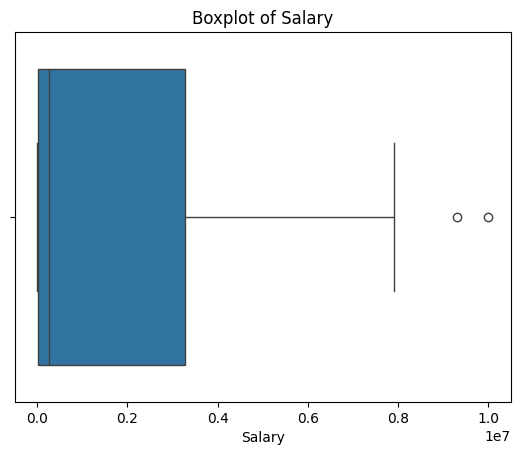

In [ ]:
sns.boxplot(x=df_no_duplicates["Salary"])
plt.title("Boxplot of Salary")
plt.show()


IQR Method

In [ ]:
Q1 = df_no_duplicates["Salary"].quantile(0.25)
Q3 = df_no_duplicates["Salary"].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

iqr_outliers = df_no_duplicates[
    (df_no_duplicates["Salary"] < lower_bound) |
    (df_no_duplicates["Salary"] > upper_bound)
]

iqr_outliers


,ID,Employee_Name,Experience_Years,Age,Gender,Salary,Is_Duplicate
27,28,Rekha,27,62,Female,10000000,False
33,34,Geetha,19,53,Female,9300000,False


Remove IQR outliers

In [ ]:
df_iqr_clean = df_no_duplicates[
    (df_no_duplicates["Salary"] >= lower_bound) &
    (df_no_duplicates["Salary"] <= upper_bound)
]
df_iqr_clean


,ID,Employee_Name,Experience_Years,Age,Gender,Salary,Is_Duplicate
0,1,Anu,5,28,Female,250000,False
1,2,Rahul,1,21,Male,50000,False
2,3,Meena,3,23,Female,170000,False
3,4,Arun,2,22,Male,25000,False
4,5,Kiran,1,17,Male,10000,False
5,6,Suresh,25,62,Male,5001000,False
6,7,Divya,19,54,Female,800000,False
7,8,Neha,2,21,Female,9000,False
8,9,Priya,10,36,Female,61500,False
9,10,Kavya,15,54,Female,650000,False


Z-Score Method

In [ ]:
from scipy.stats import zscore

df_no_duplicates["Salary_Z"] = zscore(df_no_duplicates["Salary"])

z_outliers = df_no_duplicates[
    np.abs(df_no_duplicates["Salary_Z"]) > 3
]

z_outliers


/tmp/ipython-input-3360257604.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_no_duplicates["Salary_Z"] = zscore(df_no_duplicates["Salary"])


,ID,Employee_Name,Experience_Years,Age,Gender,Salary,Is_Duplicate,Salary_Z


In [ ]:
from scipy.stats import zscore
import numpy as np

# Create a proper copy
df_no_duplicates_copy = df_no_duplicates.copy()

# Calculate Z-score
df_no_duplicates_copy["Salary_Z"] = zscore(df_no_duplicates_copy["Salary"])

# Identify outliers
z_outliers = df_no_duplicates_copy[np.abs(df_no_duplicates_copy["Salary_Z"]) > 3]

z_outliers


,ID,Employee_Name,Experience_Years,Age,Gender,Salary,Is_Duplicate,Salary_Z


4️⃣ Treating Skewed Data (Salary)
🔎 Check skewness

1️⃣ Load the dataset

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("house_prices.csv")
df


,HouseID,Area_sqft,Bedrooms,Age_Years,SalePrice
0,1,600,1,30,30000
1,2,650,1,28,32000
2,3,700,1,25,35000
3,4,750,2,24,38000
4,5,800,2,22,42000
...,...,...,...,...,...
95,96,7600,10,1,60000000
96,97,7800,10,1,65000000
97,98,8000,10,1,70000000
98,99,8200,11,1,75000000


2️⃣ Check skewness of target variable

In [ ]:
df["SalePrice"].skew()


np.float64(2.4993136615768665)

Output  being > 1 → Highly right-skewed

3️⃣ Visualize original distribution

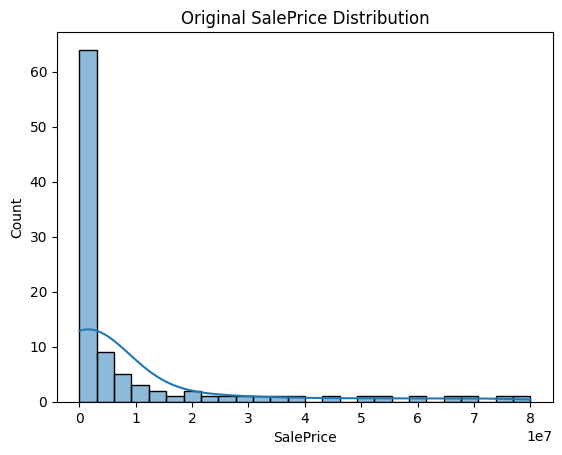

In [ ]:
sns.histplot(df["SalePrice"], kde=True)
plt.title("Original SalePrice Distribution")
plt.show()


👉 Long tail on the right = skewed data

Skewness Treatment
4️⃣ Square-Root Transformation

📐 Formula

square root of x
	​


In [ ]:
df["SalePrice_sqrt"] = np.sqrt(df["SalePrice"])

df["SalePrice_sqrt"].skew()
df


,HouseID,Area_sqft,Bedrooms,Age_Years,SalePrice,SalePrice_sqrt
0,1,600,1,30,30000,173.205081
1,2,650,1,28,32000,178.885438
2,3,700,1,25,35000,187.082869
3,4,750,2,24,38000,194.935887
4,5,800,2,22,42000,204.939015
...,...,...,...,...,...,...
95,96,7600,10,1,60000000,7745.966692
96,97,7800,10,1,65000000,8062.257748
97,98,8000,10,1,70000000,8366.600265
98,99,8200,11,1,75000000,8660.254038


Visualization

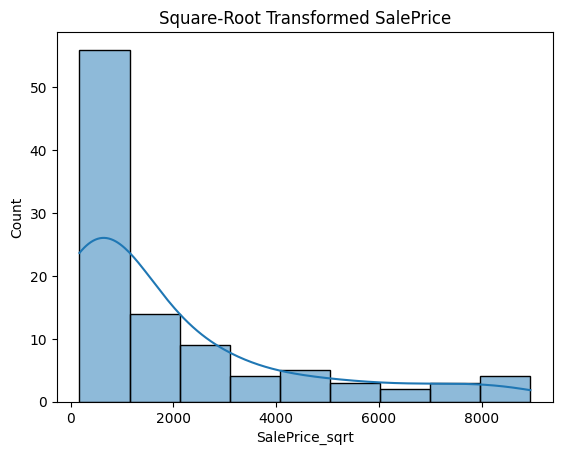

In [ ]:
sns.histplot(df["SalePrice_sqrt"], kde=True)
plt.title("Square-Root Transformed SalePrice")
plt.show()


📌 Skewness reduced, but still present

Log Transformation (Best Practice)

📐 Formula


log(X+1)

In [ ]:
df["SalePrice_log"] = np.log1p(df["SalePrice"])

df["SalePrice_log"].skew()
df


,HouseID,Area_sqft,Bedrooms,Age_Years,SalePrice,SalePrice_sqrt,SalePrice_log
0,1,600,1,30,30000,173.205081,10.308986
1,2,650,1,28,32000,178.885438,10.373522
2,3,700,1,25,35000,187.082869,10.463132
3,4,750,2,24,38000,194.935887,10.545368
4,5,800,2,22,42000,204.939015,10.645449
...,...,...,...,...,...,...,...
95,96,7600,10,1,60000000,7745.966692,17.909855
96,97,7800,10,1,65000000,8062.257748,17.989898
97,98,8000,10,1,70000000,8366.600265,18.064006
98,99,8200,11,1,75000000,8660.254038,18.132999


Visualization

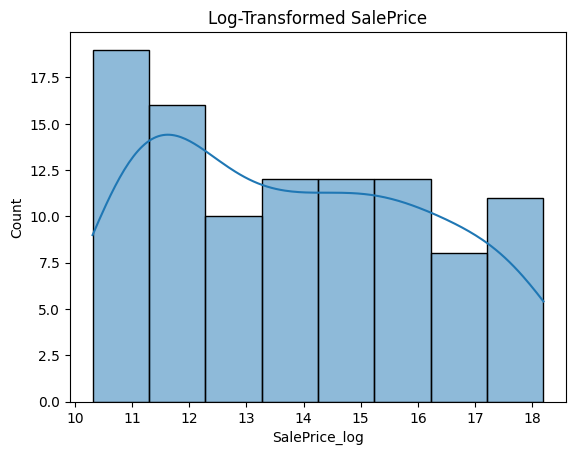

In [ ]:
sns.histplot(df["SalePrice_log"], kde=True)
plt.title("Log-Transformed SalePrice")
plt.show()


✅ Distribution becomes nearly normal

Final Transformed Dataset (Preview)

In [ ]:
df.head(50)

,HouseID,Area_sqft,Bedrooms,Age_Years,SalePrice,SalePrice_sqrt,SalePrice_log
0,1,600,1,30,30000,173.205081,10.308986
1,2,650,1,28,32000,178.885438,10.373522
2,3,700,1,25,35000,187.082869,10.463132
3,4,750,2,24,38000,194.935887,10.545368
4,5,800,2,22,42000,204.939015,10.645449
5,6,850,2,20,45000,212.132034,10.714440
6,7,900,2,18,48000,219.089023,10.778977
7,8,950,2,17,52000,228.035085,10.859018
8,9,1000,2,16,56000,236.643191,10.933125
9,10,1050,3,15,60000,244.948974,11.002117


When to Use What?
Situation	Transformation


| Situation   | Transformation |
| ----------- | -------------- |
| Mild skew   | Square-root    |
| Heavy skew  | **Log (best)** |
| Zero values | log1p          |
